# Group 3 - Assignment Code

**ECON5403 Group Assignment**

**Code Purpose:** Find best model to predict math and reading student scores based on school and teacher characteristics.

**Contents**

1. Load packages, clean data & create dummy variables

    1.1. Training sample

    1.2. Test sample

2. Model Comparison: Compare best OLS model to regularization models (Ridge, lasso, EN), tree based models (random forrest, bagging, boosting), neural network and a model average using cross-validation.

    2.1. Training sample
    
    2.2. Test sample

**Appendix:** unperpins much of the analysis in the pdf report.

3. Explore data: Summary statistics, data plots, correlations and association statistics (cramers V stats).

    3.1. Summary statistics for numeric variables.

    3.2. Summary statistics for categorical variables.

    3.3. Plot each X against test scores.

    3.4. Plot ladder against score_read and score_math.

    3.5. Multicollinearity heatmap

    3.6. Inspect non-linear relationship between experience and test scores

4. OLS linear model: use best subset and CV to select best model.

5. Regularization, Tree-based and Neural Network optimal models: finds optimal parameter values for each of these model types using cross-validation.

6. Lasso coefficients for different alphas

7. OLS Non-linear: Interaction Terms.


# 1. Load Packages, clean data & create dummy variables

We first load and clean the data, remove rows with missing values and set categorical varaibles where necessary.

We have filled the blanks in Ladder with a 'no response' variable. This allows us to keep a substantial portion of the data set. Plots in the EDA section show no_response provides information on test scores and is not random.


In [ ]:
# Load Packages and functions
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
from IPython.display import display # Used to display data in nice tables.
import seaborn as sns

!pip install dython
from dython.nominal import associations # Used for correlations and associations heat map.

# For CV:
import statsmodels.formula.api as smf # for OLS best subset (smf allows for categorical variables when searching)
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import lasso_path
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import VotingRegressor


In [ ]:
# Load data (local files)
import os
# Get the directory where this notebook is located
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
data_dir = os.path.join(notebook_dir, "..", "data")

# Load training data
df_raw = pd.read_csv(os.path.join(data_dir, "raw", "sample_kinder_data.csv"))

# Load test/validation data (using the same file as example)
db_out_raw = pd.read_csv(os.path.join(data_dir, "raw", "sample_kinder_data.csv"))


## 1.1 Training sample

In [ ]:
# Data Cleaning: Remove NAs

# Clean up the blanks in the ladder column.
df_raw['ladder'] = df_raw['ladder'].replace("", np.nan).fillna('no_response')

# Drop rows with any missing values
df = df_raw.replace("", np.nan).dropna()

# Split birth into year and quarter.
df[['year', 'quarter']] = df['birth'].str.split(' ', expand=True)

# Create a dataframe with categorical variables (useful for some ols packages, not useful for some).
df_cat = df.copy()

#Set categorical variables
catvars = [
    "gender", "birth", "year", "quarter","lunch", "ethnicity", "class_type", "school", "degree",
    "ladder", "t_ethnicity", "schooldistrict_id", "school_id"
]

# Convert categorical variables to category dtype
for col in catvars:
    df_cat[col] = df_cat[col].astype("category")

In [ ]:
# Create dummy variable dataframe.
# df with dummies is useful for ridge/lassso/elasticnet, but if used for OLS best subset it will drop some dummy variables from within a group.
# This results in the dummy variable interpretation changing. Thus should use categorical df for OLS to keep all dummies within a group.

# Drop variables with high multicollinearity:
# School_id and schooldistrict strongly correlated with 'school'. Keep school as it creates much fewer dummies with very similar info.
df = df.drop(columns=['birth', 'school_id', 'schooldistrict_id'], errors='ignore')

# Get dummies
df = pd.get_dummies(df, drop_first=True, dtype=float)

# Inspect dataframe (don't need to show in report)
#df.info()

## 1.2 Test sample

In [ ]:
# Data Cleaning: Remove NAs

# Clean up the blanks in the ladder column.
db_out_raw['ladder'] = db_out_raw['ladder'].replace("", np.nan).fillna('no_response')

# Drop rows with any missing values
df_out = db_out_raw.replace("", np.nan).dropna()

# Split birth into year and quarter.
df_out[['year', 'quarter']] = df_out['birth'].str.split(' ', expand=True)

# Create a dataframe with categorical variables (useful for some ols packages, not useful for some).
df_out_cat = df_out.copy()

#Set categorical variables
catvars = [
    "gender", "birth", "year", "quarter","lunch", "ethnicity", "class_type", "school", "degree",
    "ladder", "t_ethnicity", "schooldistrict_id", "school_id"
]

# Convert categorical variables to category dtype
for col in catvars:
    df_out_cat[col] = df_out_cat[col].astype("category")

In [ ]:
# Create dummy variable dataframe.
df_out = df_out.drop(columns=['birth', 'school_id', 'schooldistrict_id'], errors='ignore')

# Get dummies
df_out = pd.get_dummies(df_out, drop_first=True, dtype=float)


# 2. Model Comparison

Compare best OLS model to regularization models (Ridge, lasso, EN), tree based models (random forrest, bagging, boosting), neural network model (mlp) and a model average using cross-validation.

The best OLS model explanatory variables and optimal parameters for all models were found using cross-validation across various parameter value combinations. **See Appendex, sections 4 and 5 for the code**. We moved the code to the appendix as it takes a long time to run.

## 2.1. Training Sample

In [ ]:
# Model Comparison.
# Use only the optimal parameters found from code in the appendix (uses CV).

# Create any interaction terms
edu_cols = [c for c in df.columns if c.startswith("degree_")]
for c in edu_cols:
    df[f"exp_x_{c}"] = df["experience"] * df[c]

# Set Y and X variables
target_read = df["score_read"]
target_math = df["score_math"]
predictors_regularization = [col for col in df.columns if col not in ["score_read", "score_math", "exp_x_degree_master", "exp_x_degree_master+", "exp_x_degree_specialist"]]
predictors_rf = predictors_regularization
predictors_NN = predictors_regularization
predictors_ols_read = [col for col in df.columns if col not in ["score_read", "score_math", "degree_master", "degree_master+", "degree_specialist", "year_1979", "year_1980", "year_1981",
                                                                "ethnicity_amindian", "ethnicity_asian", "ethnicity_cauc", "ethnicity_hispanic", "ethnicity_other", "t_ethnicity_cauc",
                                                                "exp_x_degree_master", "exp_x_degree_master+", "exp_x_degree_specialist"]]
predictors_ols_math = [col for col in df.columns if col not in ["score_read", "score_math", "degree_master", "degree_master+", "degree_specialist", "year_1979", "year_1980", "year_1981",
                                                             "ladder_level1", "ladder_level2", "ladder_level3", "ladder_no_response", "ladder_probation", "t_ethnicity_cauc",
                                                                "exp_x_degree_master", "exp_x_degree_master+", "exp_x_degree_specialist"]]

# Set Y and X variables for non-linear OLS
predictors_ols_interaction_read = predictors_ols_read + [f"exp_x_{c}" for c in edu_cols]
predictors_ols_interaction_math = predictors_ols_math + [f"exp_x_{c}" for c in edu_cols]

# Set variables to scale
scale_cols = ["experience"]

In [ ]:
# Set CV
cv = KFold(n_splits=5, shuffle=True, random_state=1)

# Define models
models_read = [
    ("OLS", LinearRegression(), predictors_ols_read),
    ("OLS_interaction", LinearRegression(), predictors_ols_interaction_read),
    ("Ridge", Ridge(alpha=1.373824, random_state=1), predictors_regularization),
    ("LASSO", Lasso(alpha=0.011721, random_state=1), predictors_regularization),
    ("ElasticNet", ElasticNet(alpha=0.011721, l1_ratio=1.0, random_state=1), predictors_regularization),
    ("RandomForest", RandomForestRegressor(n_estimators=400,max_depth=10, max_features=0.6, min_samples_leaf=2, random_state=1), predictors_rf),
    ("BaggingDT", BaggingRegressor(n_estimators=400,max_features=0.6, max_samples=0.6, random_state=1), predictors_rf),
    ("GradBoost", GradientBoostingRegressor(n_estimators=400, max_depth=3, max_features=0.8, min_samples_leaf=1, learning_rate=0.1, subsample=1.0, random_state=1), predictors_rf),
    ("NeuralNetwork_mlp", MLPRegressor(hidden_layer_sizes=(32,32), alpha=0.0001, learning_rate_init=0.01, random_state=1), predictors_NN),
    ("model_average", VotingRegressor(estimators=[
        ("ols", LinearRegression()),
        ("lasso", Lasso(alpha=0.011721, random_state=1)),
        ("boosting", GradientBoostingRegressor(n_estimators=400, max_depth=3, max_features=0.8, min_samples_leaf=1, learning_rate=0.1, subsample=1.0, random_state=1)),
        ("nn_mlp", MLPRegressor(hidden_layer_sizes=(32,32), alpha=0.0001, learning_rate_init=0.01, random_state=1))
    ]), predictors_regularization)
]

models_math = [
    ("OLS", LinearRegression(), predictors_ols_math),
    ("OLS_interaction", LinearRegression(), predictors_ols_interaction_math),
    ("Ridge", Ridge(alpha=3.562248, random_state=1), predictors_regularization),
    ("LASSO", Lasso(alpha=0.018874, random_state=1), predictors_regularization),
    ("ElasticNet", ElasticNet(alpha=0.018874, l1_ratio=1.0, random_state=1), predictors_regularization),
    ("RandomForest", RandomForestRegressor(n_estimators=400,max_depth=10, max_features=0.6, min_samples_leaf=2, random_state=1), predictors_rf),
    ("BaggingDT", BaggingRegressor(n_estimators=400,max_features=0.6, max_samples=1.0, random_state=1), predictors_rf),
    ("GradBoost", GradientBoostingRegressor(n_estimators=400, max_depth=3, max_features=0.8, min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=1), predictors_rf),
    ("NeuralNetwork_mlp", MLPRegressor(hidden_layer_sizes=(128,64), alpha=0.01, learning_rate_init=0.01, random_state=1), predictors_NN),
    ("model_average", VotingRegressor(estimators=[
        ("ols", LinearRegression()),
        ("lasso", Lasso(alpha=0.018874)),
        ("boosting", GradientBoostingRegressor(n_estimators=400, max_depth=3, max_features=0.8, min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=1)),
        ("nn_mlp", MLPRegressor(hidden_layer_sizes=(128,64), alpha=0.01, learning_rate_init=0.01, random_state=1))
    ]), predictors_regularization)
]

# Define function to get CV MSEs for each model
def run_cv(models_with_X, y, scale_cols):
    results = []
    for name, est, cols in models_with_X:
        X = df[cols].copy()
        # scale only for linear models
        if name in {"OLS", "Ridge", "LASSO", "ElasticNet", "NeuralNetwork_mlp", "model_average"}:
            pre = ColumnTransformer([("scale", StandardScaler(), scale_cols)],
                                    remainder="passthrough")
            pipe = Pipeline([("prep", pre), ("model", est)])
        else:
            pipe = Pipeline([("prep", "passthrough"), ("model", est)])

        cv_res = cross_validate(pipe, X, y, scoring="neg_mean_squared_error", cv=cv, n_jobs=-1)
        mse = -cv_res["test_score"].mean()
        rmse = np.sqrt(mse)
        results.append({"Model": name, "MSE": mse, "RMSE": rmse})
    return pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

# Run function
read_results = run_cv(models_read, target_read, scale_cols)
math_results = run_cv(models_math, target_math, scale_cols)

# Print results
print("READ:")
print(read_results.to_string(index=False))
print("\nMATH:")
print(math_results.to_string(index=False))

READ:
            Model        MSE      RMSE
        BaggingDT 791.970110 28.141964
        GradBoost 794.179201 28.181185
     RandomForest 806.101135 28.391920
    model_average 818.888309 28.616225
       ElasticNet 866.580391 29.437738
            LASSO 866.580391 29.437738
            Ridge 867.188449 29.448064
              OLS 871.399473 29.519476
  OLS_interaction 872.212953 29.533252
NeuralNetwork_mlp 880.080642 29.666153

MATH:
            Model         MSE      RMSE
        GradBoost 1779.495963 42.184072
        BaggingDT 1789.896499 42.307168
     RandomForest 1835.022087 42.837158
    model_average 1845.806121 42.962846
NeuralNetwork_mlp 1960.443829 44.276900
            Ridge 2013.784269 44.875208
            LASSO 2014.496895 44.883147
       ElasticNet 2014.496895 44.883147
  OLS_interaction 2029.532848 45.050337
              OLS 2029.899855 45.054410


In [ ]:
# Export results to CSV
combined = pd.concat(
    [read_results.assign(Target="READ"), math_results.assign(Target="MATH")],
    ignore_index=True
)[["Target", "Model", "MSE", "RMSE"]]

# Write CSV
out_path = "cv_results_read_math.csv"
combined.to_csv(out_path, index=False)


In [ ]:
# OLS coefficients (optional):
# For READ
model_read = LinearRegression().fit(df[predictors_ols_read], target_read)
coef_df_read = pd.DataFrame({
    'Variable': predictors_ols_read,
    'Coefficient': model_read.coef_
}).sort_values('Coefficient', ascending=False)

# For MATH
model_math = LinearRegression().fit(df[predictors_ols_math], target_math)
coef_df_math = pd.DataFrame({
    'Variable': predictors_ols_math,
    'Coefficient': model_math.coef_
}).sort_values('Coefficient', ascending=False)

# Export to CSV
coef_df_read.to_csv('ols_coefficients_read.csv', index=False)
coef_df_math.to_csv('ols_coefficients_math.csv', index=False)


## 2.2 Test Sample



In [ ]:
# Model Comparison.

# Create any interaction terms
edu_cols = [c for c in df_out.columns if c.startswith("degree_")]
for c in edu_cols:
    df_out[f"exp_x_{c}"] = df_out["experience"] * df_out[c]

# Set Y and X variables
target_read = df_out["score_read"]
target_math = df_out["score_math"]
predictors_regularization = [col for col in df_out.columns if col not in ["score_read", "score_math", "exp_x_degree_master", "exp_x_degree_master+", "exp_x_degree_specialist"]]
predictors_rf = predictors_regularization
predictors_NN = predictors_regularization
predictors_ols_read = [col for col in df_out.columns if col not in ["score_read", "score_math", "degree_master", "degree_master+", "degree_specialist", "year_1979", "year_1980", "year_1981",
                                                                "ethnicity_amindian", "ethnicity_asian", "ethnicity_cauc", "ethnicity_hispanic", "ethnicity_other", "t_ethnicity_cauc",
                                                                "exp_x_degree_master", "exp_x_degree_master+", "exp_x_degree_specialist"]]
predictors_ols_math = [col for col in df_out.columns if col not in ["score_read", "score_math", "degree_master", "degree_master+", "degree_specialist", "year_1979", "year_1980", "year_1981",
                                                             "ladder_level1", "ladder_level2", "ladder_level3", "ladder_no_response", "ladder_probation", "t_ethnicity_cauc",
                                                                "exp_x_degree_master", "exp_x_degree_master+", "exp_x_degree_specialist"]]

# Set Y and X variables for non-linear OLS
predictors_ols_interaction_read = predictors_ols_read + [f"exp_x_{c}" for c in edu_cols]
predictors_ols_interaction_math = predictors_ols_math + [f"exp_x_{c}" for c in edu_cols]

# Set variables to scale
scale_cols = ["experience"]

In [ ]:
# Set CV
cv = KFold(n_splits=5, shuffle=True, random_state=1)

# Define models
models_read = [
    ("GradBoost", GradientBoostingRegressor(n_estimators=400, max_depth=3, max_features=0.8, min_samples_leaf=1, learning_rate=0.1, subsample=1.0, random_state=1), predictors_rf),
]

models_math = [
    ("GradBoost", GradientBoostingRegressor(n_estimators=400, max_depth=3, max_features=0.8, min_samples_leaf=5, learning_rate=0.1, subsample=0.8, random_state=1), predictors_rf),
]

# Define function to get CV MSEs for each model
def run_cv(models_with_X, y, scale_cols):
    results = []
    for name, est, cols in models_with_X:
        X = df_out[cols].copy()
        # scale only for linear models
        if name in {"OLS", "Ridge", "LASSO", "ElasticNet", "NeuralNetwork_mlp", "model_average"}:
            pre = ColumnTransformer([("scale", StandardScaler(), scale_cols)],
                                    remainder="passthrough")
            pipe = Pipeline([("prep", pre), ("model", est)])
        else:
            pipe = Pipeline([("prep", "passthrough"), ("model", est)])

        cv_res = cross_validate(pipe, X, y, scoring="neg_mean_squared_error", cv=cv, n_jobs=-1)
        mse = -cv_res["test_score"].mean()
        rmse = np.sqrt(mse)
        results.append({"Model": name, "MSE": mse, "RMSE": rmse})
    return pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

# Run function
read_results_out = run_cv(models_read, target_read, scale_cols)
math_results_out = run_cv(models_math, target_math, scale_cols)

# Print results
print("READ Test MSE:")
print(read_results_out.to_string(index=False))
print("\nMATH Test MSE:")
print(math_results_out.to_string(index=False))

READ Test MSE:
    Model        MSE      RMSE
GradBoost 794.179201 28.181185

MATH Test MSE:
    Model         MSE      RMSE
GradBoost 1779.495963 42.184072


# APPENDIX

# 3. Data Exploration

Contents of data exploration:

3.1. Summary statistics for numeric variables.

3.2. Summary statistics for categorical variables.

3.3. Plot each X variable against each Y (test scores) variable. Helps us get a sense of the relationships (linear, non-linear, no relationship etc.).

3.4. Plot ladder against score_read and score_math. Lets us see if 'no_response' for ladder should be removed as NA or kept.  no_response has similar scores to other low-ladder level responses (probabtion and level 1), thus provides some information about test scores. Therefore we have kept the no_responses in the dataset.

3.5. Multicollinearity heatmap. Informs us to drop school_id and schooldistrict_id as it has similar information to the school variable. Suggests variables such as t_ethnicity, degree, class_type, year, gender might not be strong predictors as have weak correlation/associations with test scores.

3.6. Inspect data for non-linear relationships between experience and test scores. It is reasonable to expect the relationship between experience and the dependent variables is logarithmic so we have decided to test this - although the evidence would suggest not. As such, we will continue to use experience in its current form.

In [ ]:
print("Numeric Variables Summary:\n")
display(df[['score_read', 'score_math', 'experience']].describe().T)

Numeric Variables Summary:



,count,mean,std,min,25%,50%,75%,max
score_read,4588.0,436.351133,31.453494,346.0,414.0,433.0,453.0,627.0
score_math,4588.0,485.485179,47.680510,339.0,454.0,484.0,513.0,626.0
experience,4588.0,9.316042,5.825823,0.0,5.0,9.0,13.0,27.0


In [ ]:
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"\n---- {col} ----")

    # Count and percent
    counts = df[col].value_counts(dropna=False)
    percents = (df[col].value_counts(dropna=False, normalize=True) * 100).round(2)

    # Create summary frame
    summary = pd.DataFrame({'Count': counts, 'Percent': percents})

    # Calculate averages for the dependent variables
    avg_scores = (
        df.groupby(col)[['score_read', 'score_math']]
        .mean()
        .round(2)
    )

    # Merge averages into summary
    summary = summary.join(avg_scores, how='left')

    # Display summary (works in any environment)
    print(summary)
    print("\n")

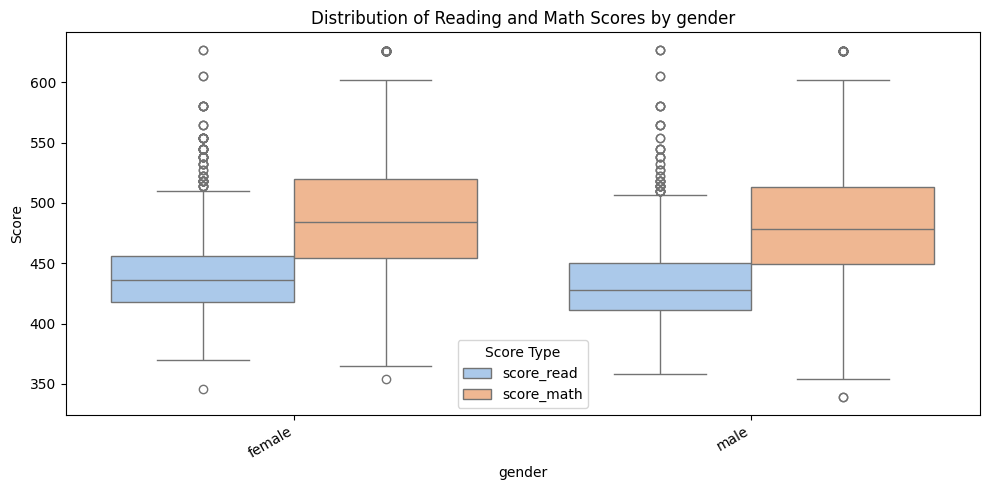

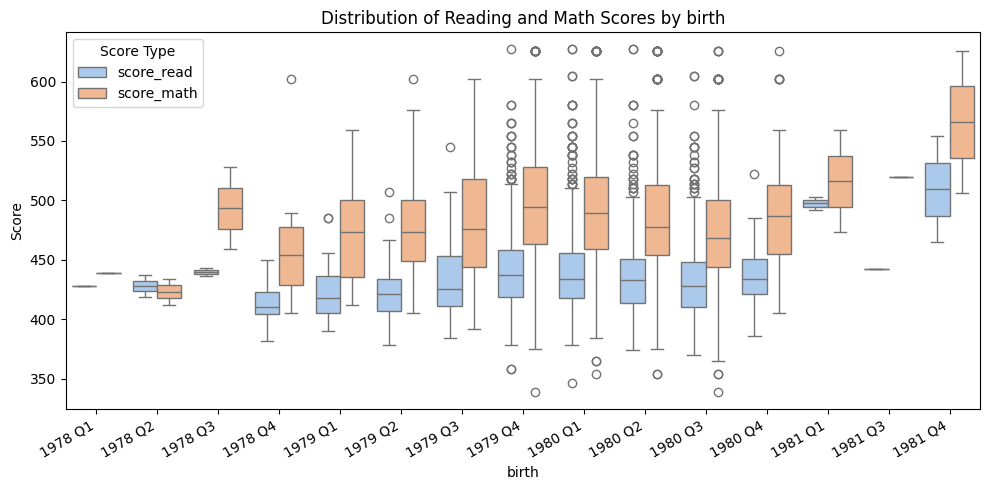

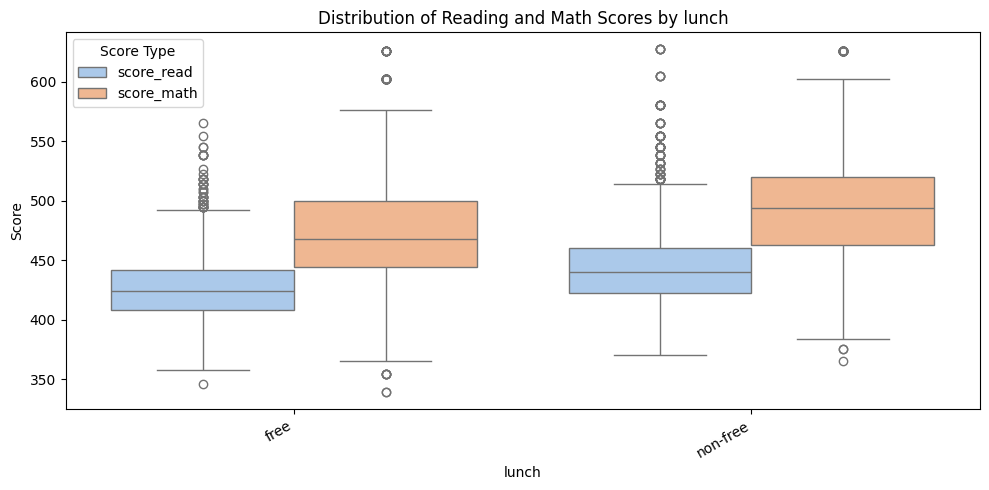

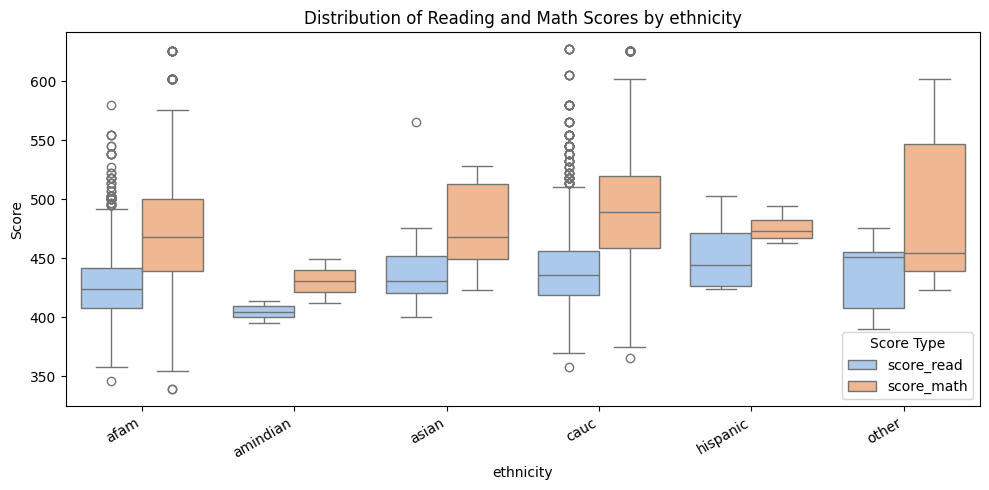

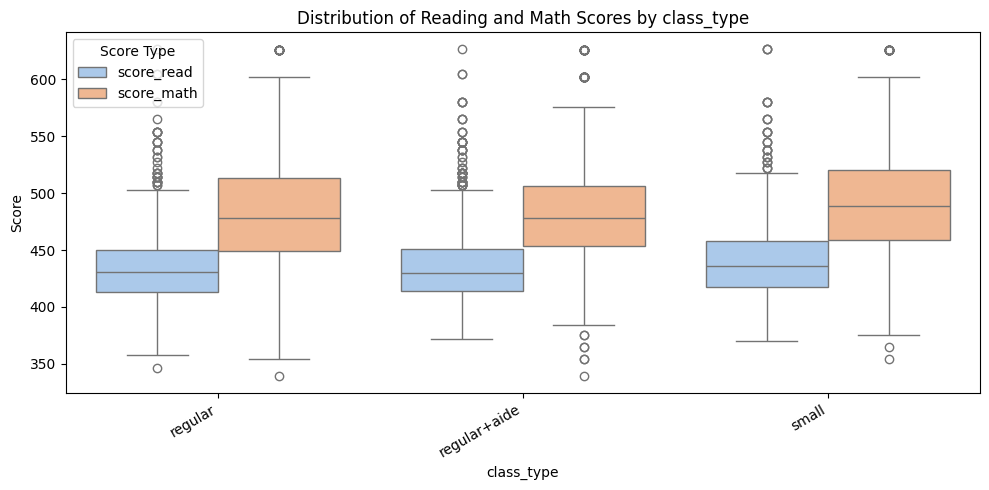

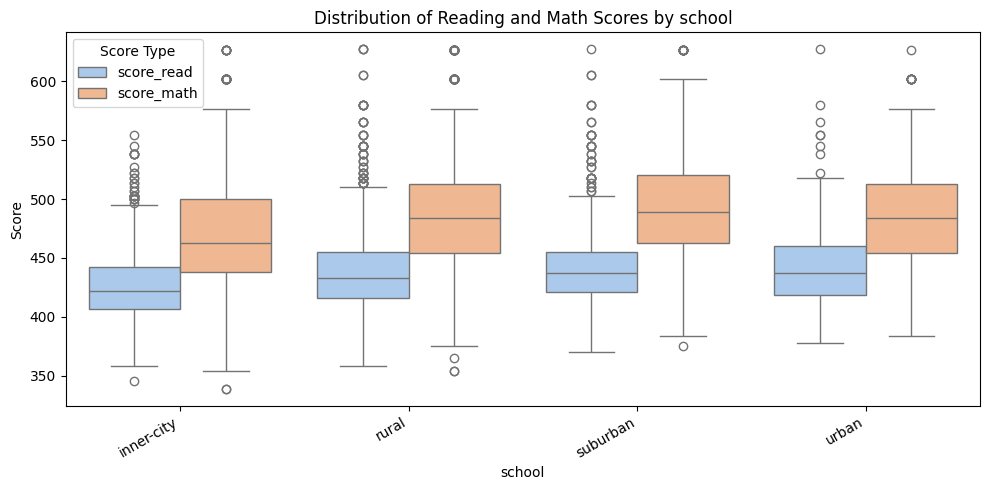

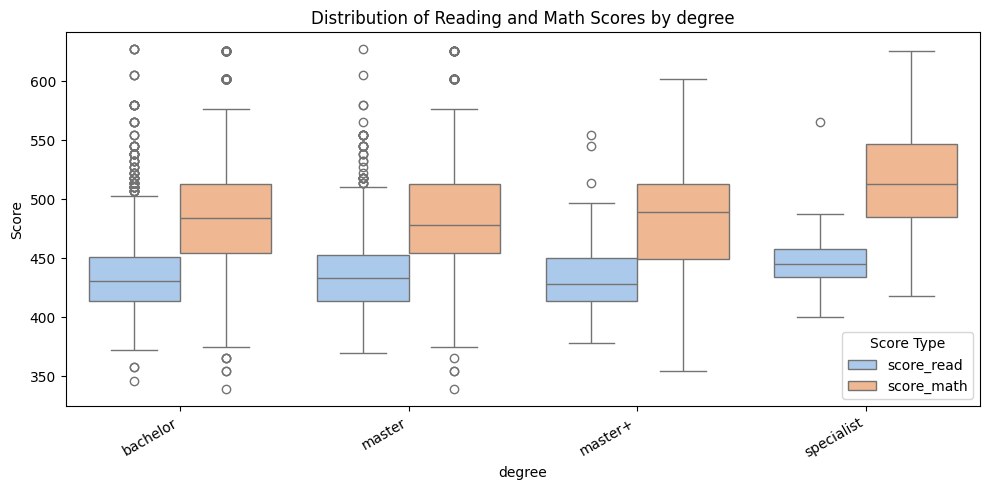

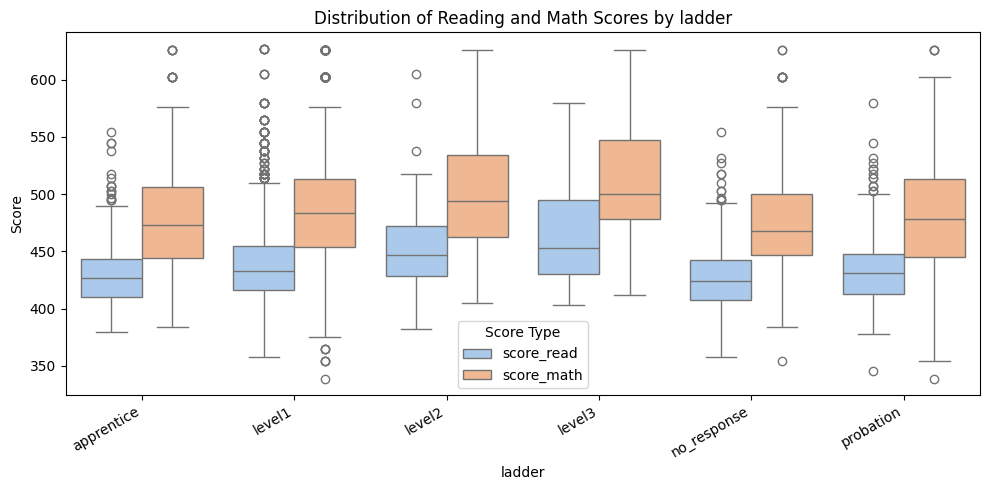

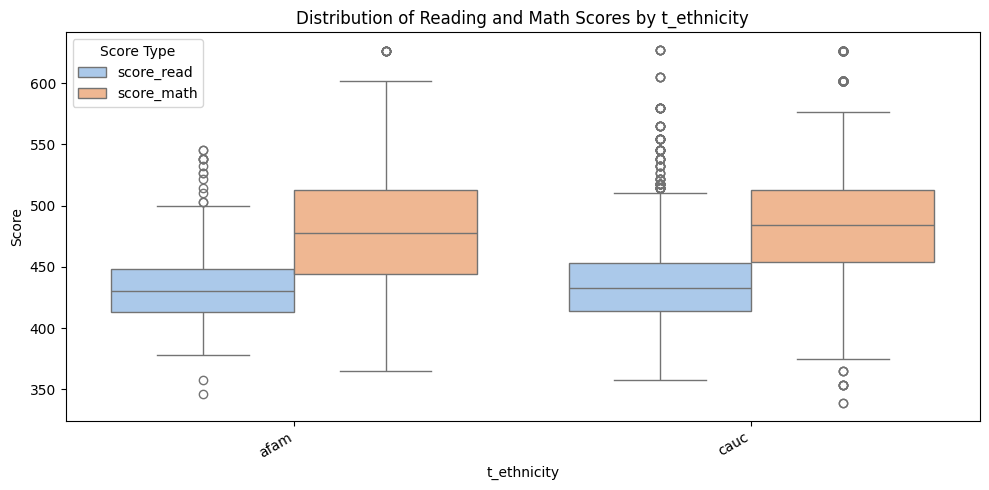

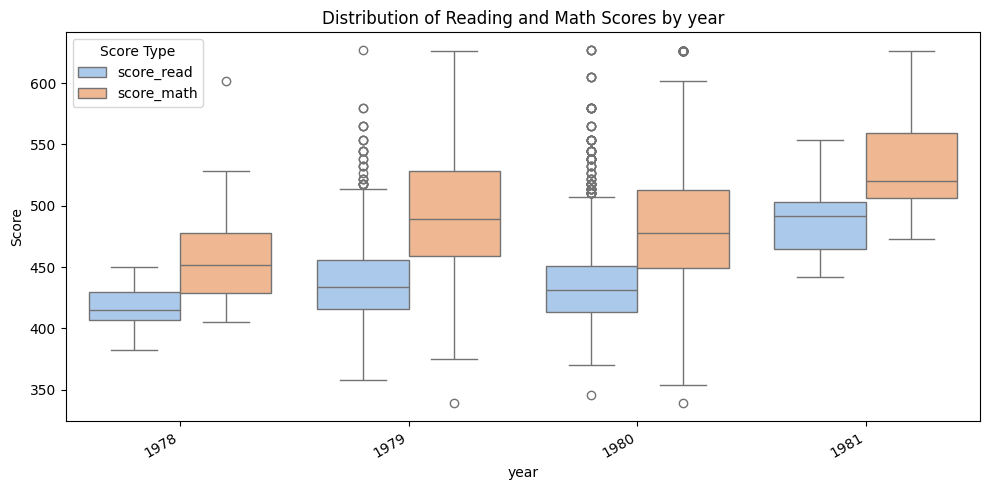

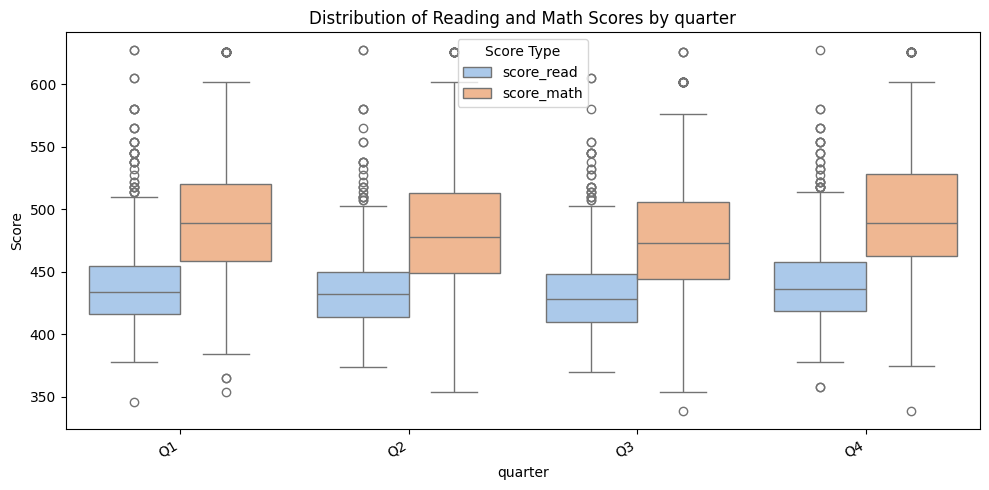

In [ ]:
# Exclude unwanted categorical variables
excluded_vars = ['school_id', 'schooldistrict_id']

# Identify categorical variables in df_cat
cat_vars_to_plot = [
    col for col in df_cat.select_dtypes(include=['object', 'category']).columns
    if col not in excluded_vars and col in df_cat.columns
]

# Ensure dependent variables exist
value_vars = [v for v in ['score_read', 'score_math'] if v in df_cat.columns]

# Loop through and create plots
for col in cat_vars_to_plot:
    if col not in df_cat.columns:
        continue  # skip missing columns

    plt.figure(figsize=(10, 5))

    # Melt only if value_vars exist
    df_melt = df_cat.melt(id_vars=[col], value_vars=value_vars,
                          var_name='Score_Type', value_name='Score')

    sns.boxplot(x=col, y='Score', hue='Score_Type', data=df_melt, palette='pastel')

    plt.title(f"Distribution of Reading and Math Scores by {col}")
    plt.xlabel(col)
    plt.ylabel("Score")
    plt.legend(title="Score Type")
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

/tmp/ipython-input-1951916280.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ladder', y='score_read', data=df_cat,


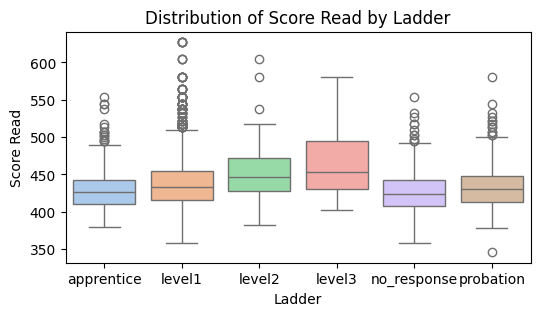

/tmp/ipython-input-1951916280.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ladder', y='score_math', data=df_cat,


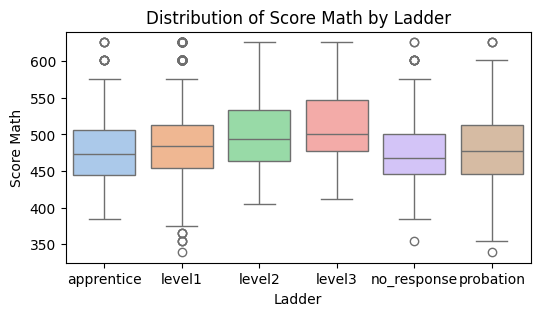

In [ ]:
# Plot no response vs read
plt.figure(figsize=(6, 3))
sns.boxplot(x='ladder', y='score_read', data=df_cat,
            order=df_cat['ladder'].cat.categories,
            palette='pastel')
plt.title('Distribution of Score Read by Ladder')
plt.xlabel('Ladder')
plt.ylabel('Score Read')
plt.show()

# Plot no response vs math
plt.figure(figsize=(6, 3))
sns.boxplot(x='ladder', y='score_math', data=df_cat,
            order=df_cat['ladder'].cat.categories,
            palette='pastel')
plt.title('Distribution of Score Math by Ladder')
plt.xlabel('Ladder')
plt.ylabel('Score Math')
plt.show()

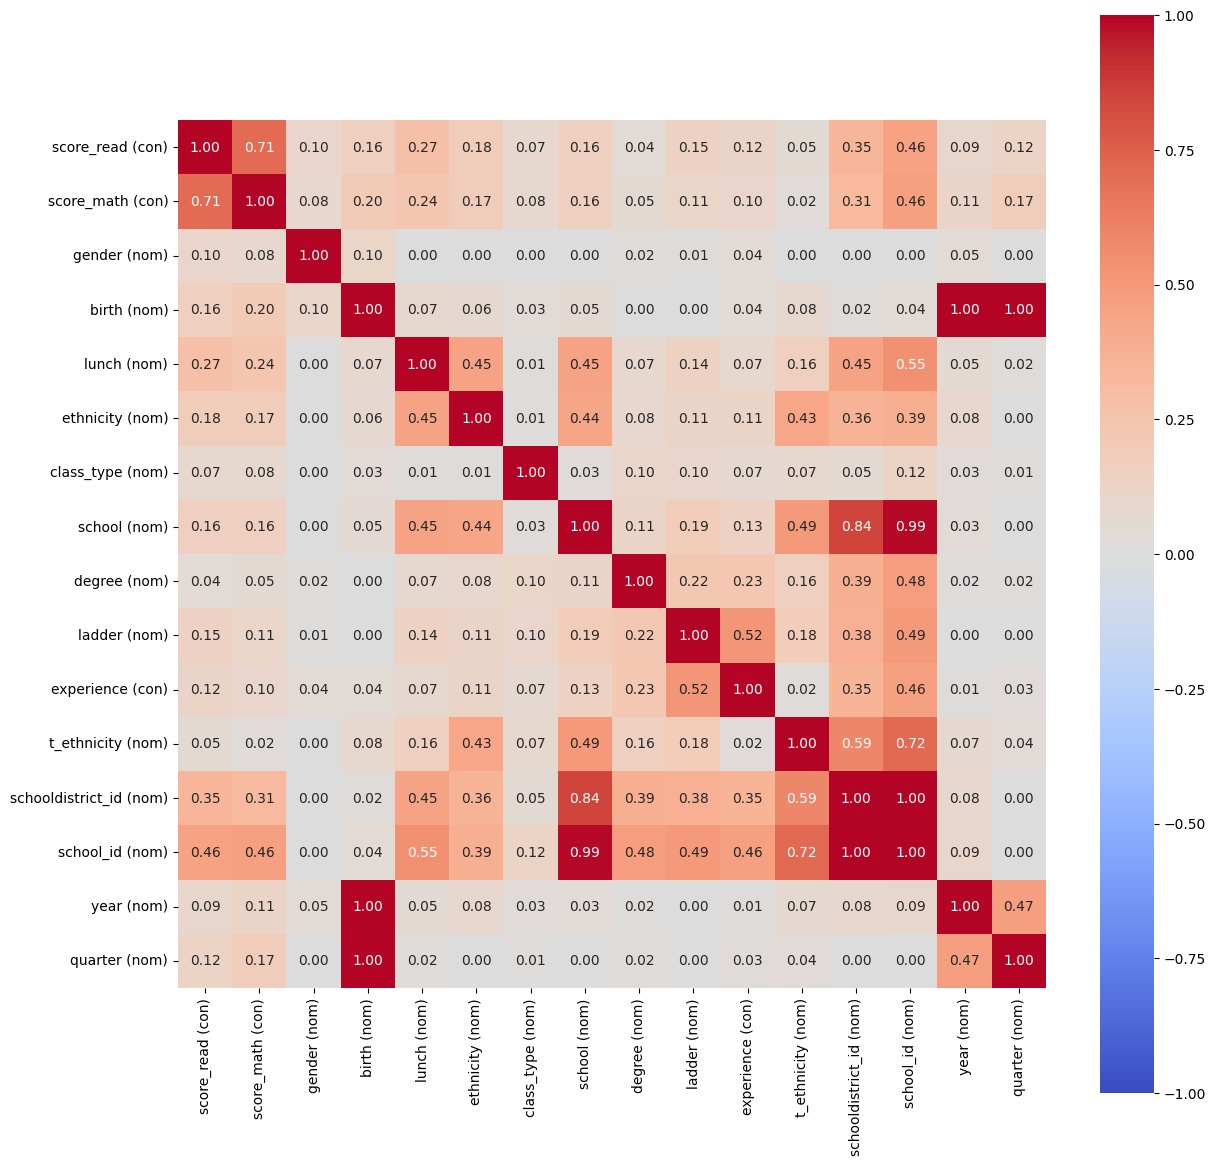

In [ ]:
# Data Cleaning: Inspect Correlations and Associations. Informs us if we can drop some variables before making dummies.
# numeric-numeric = pearsons correlation
# numeric-cat = correlation ratio (share of variation explained)
# cat-cat = cramers V bias corrected (measure of association for cat variables)

# Create heatmap for correlations and associations
associations(df_cat, figsize=(14, 14), cmap='coolwarm', mark_columns=True)
plt.show()

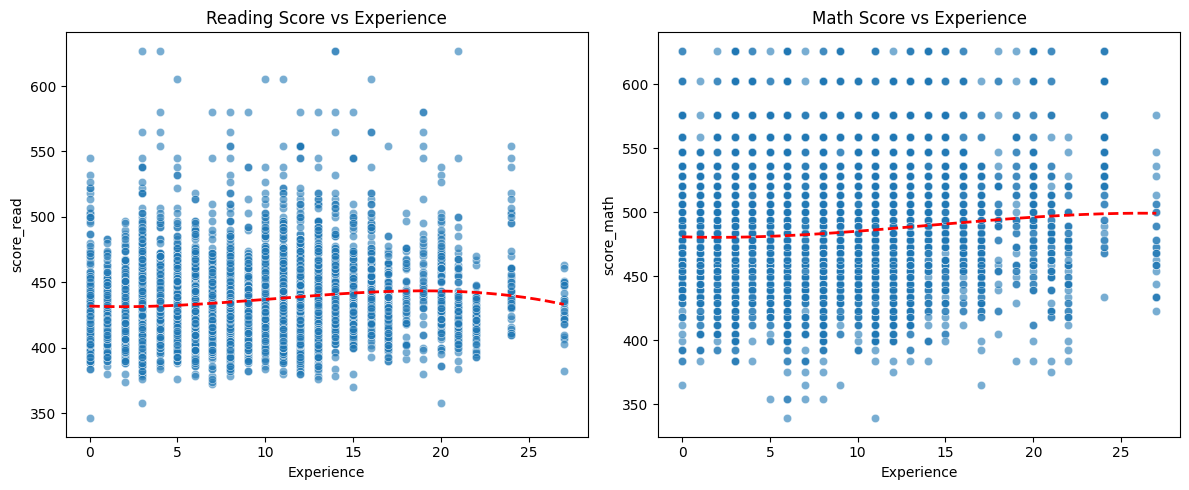

In [ ]:
plt.figure(figsize=(12, 5))

# Function to plot scatter + polynomial fit
def scatter_poly(x, y, order=2, ax=None, title=''):
    if ax is None:
        ax = plt.gca()
    # Scatter points
    sns.scatterplot(x=x, y=y, alpha=0.6, ax=ax)

    # Polynomial fit
    coeffs = np.polyfit(x, y, deg=order)           # Fit polynomial
    x_fit = np.linspace(x.min(), x.max(), 200)     # Smooth x values
    y_fit = np.polyval(coeffs, x_fit)              # Evaluate polynomial

    # Plot polynomial line
    ax.plot(x_fit, y_fit, 'r--', linewidth=2)      # red dotted line
    ax.set_title(title)
    ax.set_xlabel('Experience')
    ax.set_ylabel(y.name)

# Scatter 1: Reading score vs experience with cubic fit
ax1 = plt.subplot(1, 2, 1)
scatter_poly(df['experience'], df['score_read'], order=3, ax=ax1, title='Reading Score vs Experience')

# Scatter 2: Math score vs experience with cubic fit
ax2 = plt.subplot(1, 2, 2)
scatter_poly(df['experience'], df['score_math'], order=3, ax=ax2, title='Math Score vs Experience')

plt.tight_layout()
plt.show()

# 4. OLS Best Subset Model

Takes around 30 minutes to run.

4.1. Prints the best (lowest MSE) OLS model for read and math test scores and for each number of predictors.

4.2. Plots RMSE (sqrt(MSE)) for read and math as number of predictors increase. Tells us that the improved performance is extremely marginal after 5-6 predictors. Given our preference for lower bias (i.e. a simpler model), we limit the number of predictors in our preferred OLS model to 6.

In [ ]:
# OLS Linear Model. (30 minutes to run)
# THIS VERSION RETURNS BEST MODEL AND MSE FOR EACH K
# I find the best model subset using Cross Validation.
# Use the df_cat becuase it keeps the dummy variables grouped, and thus interpretable.

# Set Y and X variables
target = "score_read"
predictors = ["gender", "lunch", "ethnicity", "class_type", "school", "degree",
    "ladder", "t_ethnicity", "year", "quarter", "experience"]

# Define how to split the data for later
cv = KFold(n_splits=5, shuffle=True, random_state=1)

# Create CV function that stores MSE
def cv_mse(subset):
    # Set regression model formula. Creates dummies for categorical variables.
    f = f"{target} ~ " + " + ".join([f"C({v})" if df_cat[v].dtype.name=="category" else v for v in subset])
    # create mse list to store mse results
    mse=[]
    # Loop that iterates through train and test split for a given model. Get MSE
    for tr,te in cv.split(df_cat):
        m=smf.ols(f, data=df_cat.iloc[tr]).fit()
        p=m.predict(df_cat.iloc[te])
        mse.append(mean_squared_error(df_cat.iloc[te][target],p))
    return np.mean(mse)

# Loop over data using cv_mse function for every possible subset of predictors. Prints message every 100 models
best_read=(None,np.inf)
best_by_k_read = {}
count = 0
for k in range(1,len(predictors)+1):
    best_k = (None, np.inf)
    for s in itertools.combinations(predictors,k):
        # print message for every 100 rows.
        count += 1
        if count % 100 == 0:
            print(f"Processed {count} models...")
        m=cv_mse(s)
        if m<best_k[1]: best_k=(s,m)
        if m<best_read[1]: best_read=(s,m)
    best_by_k_read[k] = best_k
    print(f"k={k}: bets CV MSE={best_k[1]:.6f} with {best_k[0]}")

# Repeat for maths
target = "score_math"
best_math=(None,np.inf)
best_by_k_math = {}
count = 0
for k in range(1,len(predictors)+1):
    best_k = (None, np.inf)
    for s in itertools.combinations(predictors,k):
        # print message for every 100 rows.
        count += 1
        if count % 100 == 0:
            print(f"Processed {count} models...")
        m=cv_mse(s)
        if m<best_k[1]: best_k=(s,m)
        if m<best_math[1]: best_math=(s,m)
    best_by_k_math[k] = best_k
    print(f"k={k}: best CV MSE={best_k[1]:.6f} with {best_k[0]}")

# Print best model
print("\nBest read model (overall):",best_read[0])
print("CV MSE read:",best_read[1])

print("\nBest math model (overall):",best_math[0])
print("CV MSE math:",best_math[1])

k=1: bets CV MSE=915.598987 with ('lunch',)
k=2: bets CV MSE=902.648955 with ('lunch', 'ladder')
Processed 100 models...
Processed 200 models...
k=3: bets CV MSE=890.812647 with ('lunch', 'ladder', 'quarter')
Processed 300 models...
Processed 400 models...
Processed 500 models...
k=4: bets CV MSE=881.627568 with ('gender', 'lunch', 'ladder', 'quarter')
Processed 600 models...
Processed 700 models...
Processed 800 models...
Processed 900 models...
Processed 1000 models...
k=5: bets CV MSE=876.043395 with ('gender', 'lunch', 'class_type', 'ladder', 'quarter')
Processed 1100 models...
Processed 1200 models...
Processed 1300 models...
Processed 1400 models...
k=6: bets CV MSE=873.127042 with ('gender', 'lunch', 'class_type', 'ladder', 'quarter', 'experience')
Processed 1500 models...
Processed 1600 models...
Processed 1700 models...
Processed 1800 models...
k=7: bets CV MSE=870.318558 with ('gender', 'lunch', 'class_type', 'ladder', 'year', 'quarter', 'experience')
Processed 1900 models...

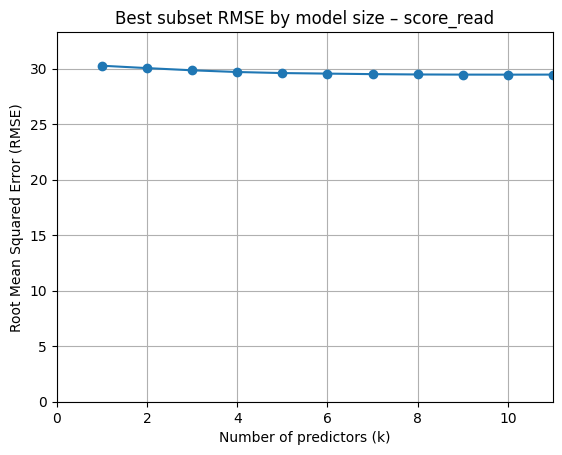

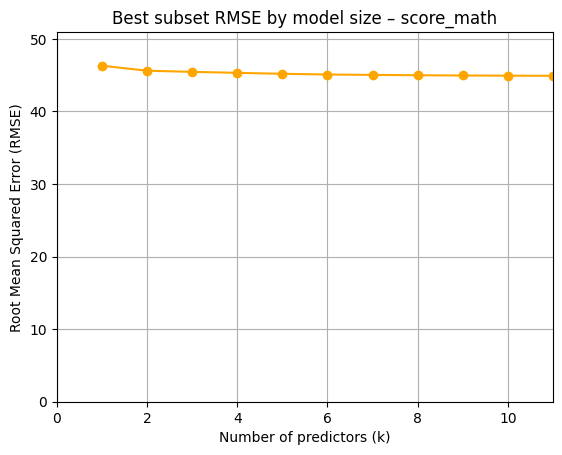

In [ ]:
# Plots the RMSE (MSE but in actual units of score_read and score_math) for different k.

# ---- Plot for READ ----
k_vals = list(best_by_k_read.keys())
rmse_vals = [np.sqrt(v[1]) for v in best_by_k_read.values()]  # take square root

plt.figure()
plt.plot(k_vals, rmse_vals, marker='o')
plt.xlabel("Number of predictors (k)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("Best subset RMSE by model size – score_read")
plt.xlim(0, max(k_vals))  # start x-axis from 0
plt.ylim(0, max(rmse_vals) * 1.1)  # keep y-axis starting at 0 automatically
plt.grid(True)
plt.show()

# ---- Plot for MATH ----
k_vals_m = list(best_by_k_math.keys())
rmse_vals_m = [np.sqrt(v[1]) for v in best_by_k_math.values()]

plt.figure()
plt.plot(k_vals_m, rmse_vals_m, marker='o', color='orange')
plt.xlabel("Number of predictors (k)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("Best subset RMSE by model size – score_math")
plt.xlim(0, max(k_vals_m))
plt.ylim(0, max(rmse_vals_m) * 1.1)
plt.grid(True)
plt.show()

# 5. Model Parameters: Regularization, Tree-based models, Neural networks

5.1. Defines function to run cross validation for each model type and compare MSE.

5.2. Gets optimal parameter values for:
  
    2.1. Regularization: Optimal alphas and l1_ratio

    2.2. Tree-based: optimal number of trees, depth, min_samples, max_features, learning rates etc.

    2.3. Neural networks: layer size and depth

5.3. Displays table with optimal parameters

In [ ]:
# Create objects to store optimal parameters
params_read = {}
params_math = {}

In [ ]:
# Define function for CV
def find_optimal_params(models, target, params_dict, scale_cols):
    for name, est, cols in models:
        X = df[cols].copy()
        pre = ColumnTransformer([("scale", StandardScaler(), scale_cols)],
                                remainder="passthrough")
        pipe = Pipeline([("prep", pre), ("model", est)])

        pipe.fit(X, target)
        model = pipe.named_steps["model"]

        # GridSearchCV case
        if hasattr(model, "best_params_"):
            params_dict[name] = model.best_params_

        # RidgeCV / LassoCV / ElasticNetCV
        elif hasattr(model, "alpha_"):
            params_dict[name] = {"alpha": model.alpha_}
            if hasattr(model, "l1_ratio_"):
                params_dict[name]["l1_ratio"] = model.l1_ratio_

        # Plain models (OLS, etc.)
        else:
            params_dict[name] = {}

In [ ]:
# Run Regularization CV
models = [
    ("Ridge", RidgeCV(alphas=np.logspace(-4,2,30), cv=5, scoring="neg_mean_squared_error"), predictors_regularization),
    ("LASSO", LassoCV(alphas=np.logspace(-4,2,30), cv=5, random_state=1, n_jobs = -1), predictors_regularization),
    ("Elastic Net", ElasticNetCV(alphas=np.logspace(-4,2,30),
                                 l1_ratio=[0.001,0.1,0.5,0.9,1],
                                 cv=5, random_state=1, n_jobs = -1), predictors_regularization),]
# Run CV
find_optimal_params(models, target_read, params_read, scale_cols)
find_optimal_params(models, target_math, params_math, scale_cols)


In [ ]:
# Run Tree-based models CV

# RF: averages many decorrelated trees
#     n_estimators: number of trees used (lower = more bias but less variance)
#     max_depth: number of layers in the tree. More layers = higher fit, but risks overfitting.
#     min_samples_leaf: minimum number of observations per leaf. Can use low number as RF should reduce variance by averaging over many trees.
#     max_features: number of predictor variables used for each split of the tree.

# 20 mins to run
models = [
    ("RandomForest", GridSearchCV(RandomForestRegressor(random_state=1, n_jobs=-1),
                                  param_grid={"n_estimators": [100,200,300,400], "max_depth": [None, 5, 10, 20], "min_samples_leaf": [1, 2, 5], "max_features": [0.6,0.8,1.0]},
                                  scoring="neg_mean_squared_error", cv=3, n_jobs=-1,), predictors_rf)]

# Run CV
find_optimal_params(models, target_read, params_read, scale_cols)
find_optimal_params(models, target_math, params_math, scale_cols)


In [ ]:
# Bagging: full-depth trees on bootstrapped samples. Higher correlation among trees than RF.
#     n_estimators: number of trees used (lower = more bias but less variance)
#     max_samples:
#     max_features: number of predictor variables used for each split of the tree.
# 6 mins to run
models = [
    ("BaggingDT", GridSearchCV(BaggingRegressor(estimator=DecisionTreeRegressor(random_state=1),random_state=1, n_jobs=1),
                               param_grid={"n_estimators": [100,200,300,400], "max_samples": [0.6,0.8,1.0], "max_features": [0.6,0.8,1.0]},
                               scoring="neg_mean_squared_error", cv=3, n_jobs=-1,), predictors_rf)]

find_optimal_params(models, target_read, params_read, scale_cols)
find_optimal_params(models, target_math, params_math, scale_cols)

In [ ]:
# Boosting: combines shallow decision trees, correcting errors from previous trees.
#     n_estimators: number of trees used (lower = more bias but less variance)
#     max_depth: number of layers in the tree. More layers = higher fit, but risks overfitting.
#     min_samples_leaf: minimum number of observations per leaf. Can use low number as RF should reduce variance by averaging over many trees.
#     Learning rate: how strongly the model corrects errors. Usual range between 0.05 and 0.1
# 11 mins to run
models = [
    ("GradBoost", GridSearchCV(GradientBoostingRegressor(random_state=1),
                              param_grid={"n_estimators": [100,200,300,400], "learning_rate": [0.05,0.075,0.1], "max_depth": [3], "subsample": [0.6,0.8,1.0],
                                          "min_samples_leaf": [1,5], "max_features": [0.6,0.8,1.0]},
                              scoring="neg_mean_squared_error", cv=3, n_jobs=-1,), predictors_rf)]

find_optimal_params(models, target_read, params_read, scale_cols)
find_optimal_params(models, target_math, params_math, scale_cols)

In [ ]:
# Run Neural Network Models
# MLP (feed-forward network)

models = [
    ('NN_mlp', GridSearchCV(MLPRegressor(random_state=1, solver="adam"),
                            param_grid={"hidden_layer_sizes": [(32,32), (64,64), (128,64), (128,128)], "activation": ["relu"], "alpha": [1e-4, 1e-3, 1e-2], "learning_rate_init": [1e-3, 5e-3, 1e-2]},
                            scoring = "neg_mean_squared_error", cv=3, n_jobs=-1), predictors_rf)
]

find_optimal_params(models, target_read, params_read, scale_cols)
find_optimal_params(models, target_math, params_math, scale_cols)

In [ ]:
# Display optimal parameters

# READ
df_read_params = pd.DataFrame(
    [{"Model": k, **v} for k, v in params_read.items()]
).fillna("")
display(df_read_params)

# MATH
df_math_params = pd.DataFrame(
    [{"Model": k, **v} for k, v in params_math.items()]
).fillna("")
display(df_math_params)

,Model,alpha,l1_ratio,max_depth,max_features,min_samples_leaf,n_estimators,max_samples,learning_rate,subsample,activation,hidden_layer_sizes,learning_rate_init
0,Ridge,1.373824,,,,,,,,,,,
1,LASSO,0.011721,,,,,,,,,,,
2,Elastic Net,0.011721,1.0,,,,,,,,,,
3,RandomForest,,,10.0,0.6,2.0,400.0,,,,,,
4,BaggingDT,,,,0.6,,400.0,0.6,,,,,
5,GradBoost,,,3.0,0.8,1.0,400.0,,0.1,1.0,,,
6,NN_mlp,0.0001,,,,,,,,,relu,"(32, 32)",0.01


,Model,alpha,l1_ratio,max_depth,max_features,min_samples_leaf,n_estimators,max_samples,learning_rate,subsample,activation,hidden_layer_sizes,learning_rate_init
0,Ridge,3.562248,,,,,,,,,,,
1,LASSO,0.018874,,,,,,,,,,,
2,Elastic Net,0.018874,1.0,,,,,,,,,,
3,RandomForest,,,10.0,0.6,2.0,400.0,,,,,,
4,BaggingDT,,,,0.6,,400.0,1.0,,,,,
5,GradBoost,,,3.0,0.8,5.0,400.0,,0.1,0.8,,,
6,NN_mlp,0.01,,,,,,,,,relu,"(128, 64)",0.01


# 6. Ridge & Lasso: Coefficient values for different alphas

Regularisation of LASSO coefficients is illustrated in the chart below. Code saves csv file if you want to inspect the values (as the graph is a bit hard to interpret).



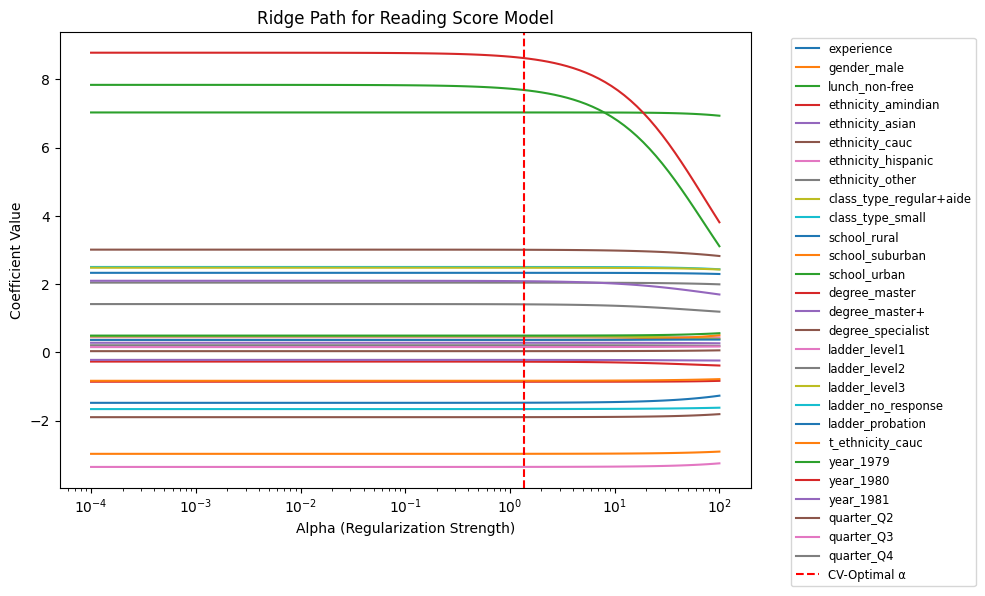

In [ ]:
# Use your predictors and target
X = df[predictors_regularization].copy()
y = target_read  # or target_math

# Standardize predictors before computing the path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ridge_regression
X_scaled = StandardScaler().fit_transform(X)

# Compute Ridge path manually since sklearn has no ridge_path() helper like lasso_path
alphas_ridge = np.logspace(-4, 2, 100)
coefs_ridge = np.array([
    ridge_regression(X_scaled, y, alpha=a)
    for a in alphas_ridge
])

# Plot coefficient paths
plt.figure(figsize=(10, 6))
for coef, name in zip(coefs_ridge.T, X.columns):
    plt.plot(alphas_ridge, coef, label=name)

plt.xscale("log")
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("Coefficient Value")
plt.title("Ridge Path for Reading Score Model")
plt.axvline(params_read["Ridge"]["alpha"], color='red', linestyle='--', label='CV-Optimal α')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

# Show graph values in table
coef_table_ridge = pd.DataFrame(
    coefs_ridge,  # shape (n_alphas, n_features)
    index=alphas_ridge,
    columns=X.columns
)

coef_table_ridge.index.name = "alpha"

# Export
coef_table_ridge.to_csv("ridge_path_table.csv")

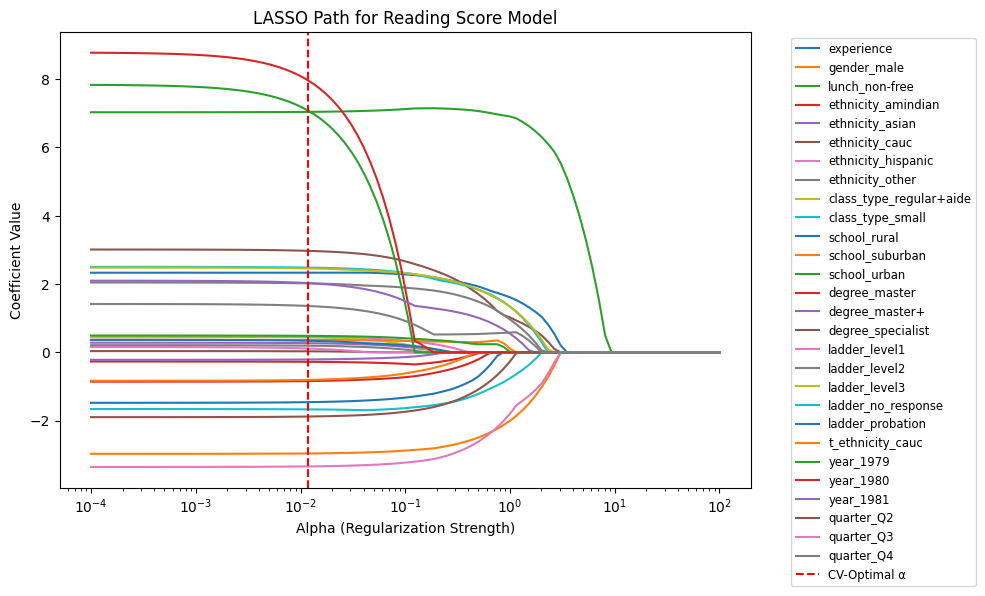

In [ ]:
# Use your predictors and target
X = df[predictors_regularization].copy()
y = target_read  # or target_math

# Standardize predictors before computing the path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import lasso_path
X_scaled = StandardScaler().fit_transform(X)

# Compute LASSO path
alphas_lasso, coefs_lasso, _ = lasso_path(X_scaled, y, alphas=np.logspace(-4, 2, 100))

# Plot coefficient paths
plt.figure(figsize=(10, 6))
for coef, name in zip(coefs_lasso, X.columns):
    plt.plot(alphas_lasso, coef, label=name)

plt.xscale("log")
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("Coefficient Value")
plt.title("LASSO Path for Reading Score Model")
plt.axvline(params_read["LASSO"]["alpha"], color='red', linestyle='--', label='CV-Optimal α')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

# Show graph values in table
coef_table = pd.DataFrame(
    coefs_lasso.T,  # shape (n_alphas, n_features)
    index=alphas_lasso,
    columns=X.columns
)

coef_table.index.name = "alpha"

# If you want to export it
coef_table.to_csv("lasso_path_table.csv")

# 7. OLS Non-linear: Interaction Terms.

This section evaluates the usefulness of including an interaction term between teacher experience and teacher degree.

In [ ]:
# ------------------------------------------------------------
# OLS with Interaction Term: experience * degree
# ------------------------------------------------------------

from sklearn.metrics import mean_squared_error
import statsmodels.formula.api as smf

# Define KFold
cv = KFold(n_splits=5, shuffle=True, random_state=1)

# ---- For Reading ----
target = "score_read"
formula_read = f"{target} ~ " + " + ".join([
    f"C({v})" if df_cat[v].dtype.name == "category" else v
    for v in ["gender", "lunch", "ethnicity", "class_type", "school",
              "degree", "ladder", "t_ethnicity", "year", "quarter", "experience"]
]) + " + experience:degree"

mse_read = []
for tr, te in cv.split(df_cat):
    model = smf.ols(formula_read, data=df_cat.iloc[tr]).fit()
    preds = model.predict(df_cat.iloc[te])
    mse_read.append(mean_squared_error(df_cat.iloc[te][target], preds))
cv_mse_read_inter = np.mean(mse_read)

print(f"\nCV MSE (OLS + Interaction) – Reading: {cv_mse_read_inter:.5f}")

# ---- For Math ----
target = "score_math"
formula_math = f"{target} ~ " + " + ".join([
    f"C({v})" if df_cat[v].dtype.name == "category" else v
    for v in ["gender", "lunch", "ethnicity", "class_type", "school",
              "degree", "ladder", "t_ethnicity", "year", "quarter", "experience"]
]) + " + experience:degree"

mse_math = []
for tr, te in cv.split(df_cat):
    model = smf.ols(formula_math, data=df_cat.iloc[tr]).fit()
    preds = model.predict(df_cat.iloc[te])
    mse_math.append(mean_squared_error(df_cat.iloc[te][target], preds))
cv_mse_math_inter = np.mean(mse_math)

print(f"CV MSE (OLS + Interaction) – Math: {cv_mse_math_inter:.5f}")



CV MSE (OLS + Interaction) – Reading: 864.50377
CV MSE (OLS + Interaction) – Math: 2000.42492


In [ ]:
# ============================================================
# Summarize OLS Best Subset Results and Interaction Model
# ============================================================

# --- 1️⃣ Best subset variables and CV MSE ---
best_read_vars = best_read[0]
best_read_mse = best_read[1]
best_math_vars = best_math[0]
best_math_mse = best_math[1]

print("---- BEST SUBSET MODELS ----")
print(f"Reading best subset (k={len(best_read_vars)}): {best_read_vars}")
print(f"CV MSE (Reading): {best_read_mse:.5f}")
print(f"Math best subset (k={len(best_math_vars)}): {best_math_vars}")
print(f"CV MSE (Math): {best_math_mse:.5f}")

# --- 2️⃣ Compare to interaction term models ---
print("\n---- INTERACTION MODELS ----")
print(f"CV MSE (Reading + interaction): {cv_mse_read_inter:.5f}")
print(f"CV MSE (Math + interaction): {cv_mse_math_inter:.5f}")

# --- 3️⃣ Select the best (lowest MSE) model for each target ---
if best_read_mse < cv_mse_read_inter:
    best_model_read_type = "Best Subset"
    final_formula_read = f"score_read ~ " + " + ".join(
        [f'C({v})' if df_cat[v].dtype.name=='category' else v for v in best_read_vars])
else:
    best_model_read_type = "Interaction"
    final_formula_read = formula_read

if best_math_mse < cv_mse_math_inter:
    best_model_math_type = "Best Subset"
    final_formula_math = f"score_math ~ " + " + ".join(
        [f'C({v})' if df_cat[v].dtype.name=='category' else v for v in best_math_vars])
else:
    best_model_math_type = "Interaction"
    final_formula_math = formula_math

print(f"\n✅ Selected best model for READING: {best_model_read_type}")
print(f"Formula: {final_formula_read}")
print(f"✅ Selected best model for MATH: {best_model_math_type}")
print(f"Formula: {final_formula_math}")

# --- 4️⃣ Fit the final selected models on the full dataset ---
model_read_final = smf.ols(final_formula_read, data=df_cat).fit()
model_math_final = smf.ols(final_formula_math, data=df_cat).fit()

# --- 5️⃣ Create coefficient + SE summary tables ---
coef_table_read = pd.DataFrame({
    "Coefficient": model_read_final.params,
    "Std. Error": model_read_final.bse,
    "t-Value": model_read_final.tvalues,
    "p-Value": model_read_final.pvalues
}).round(4)

coef_table_math = pd.DataFrame({
    "Coefficient": model_math_final.params,
    "Std. Error": model_math_final.bse,
    "t-Value": model_math_final.tvalues,
    "p-Value": model_math_final.pvalues
}).round(4)

print("\n---- FINAL MODEL: READING ----")
display(coef_table_read)
print(f"R² = {model_read_final.rsquared:.4f}")

print("\n---- FINAL MODEL: MATH ----")
display(coef_table_math)
print(f"R² = {model_math_final.rsquared:.4f}")


---- BEST SUBSET MODELS ----
Reading best subset (k=10): ('gender', 'lunch', 'ethnicity', 'class_type', 'school', 'ladder', 't_ethnicity', 'year', 'quarter', 'experience')
CV MSE (Reading): 867.64152
Math best subset (k=11): ('gender', 'lunch', 'ethnicity', 'class_type', 'school', 'degree', 'ladder', 't_ethnicity', 'year', 'quarter', 'experience')
CV MSE (Math): 2016.57759

---- INTERACTION MODELS ----
CV MSE (Reading + interaction): 864.50377
CV MSE (Math + interaction): 2000.42492

✅ Selected best model for READING: Interaction
Formula: score_read ~ C(gender) + C(lunch) + C(ethnicity) + C(class_type) + C(school) + C(degree) + C(ladder) + C(t_ethnicity) + C(year) + C(quarter) + experience + experience:degree
✅ Selected best model for MATH: Interaction
Formula: score_math ~ C(gender) + C(lunch) + C(ethnicity) + C(class_type) + C(school) + C(degree) + C(ladder) + C(t_ethnicity) + C(year) + C(quarter) + experience + experience:degree

---- FINAL MODEL: READING ----


,Coefficient,Std. Error,t-Value,p-Value
Intercept,408.5924,6.1776,66.1412,0.0000
C(gender)[T.male],-5.9878,0.8723,-6.8645,0.0000
C(lunch)[T.non-free],14.2561,1.0142,14.0563,0.0000
C(ethnicity)[T.amindian],-13.8613,20.9685,-0.6611,0.5086
C(ethnicity)[T.asian],5.4067,8.9636,0.6032,0.5464
C(ethnicity)[T.cauc],6.5992,1.5085,4.3747,0.0000
C(ethnicity)[T.hispanic],16.0668,14.7399,1.0900,0.2758
C(ethnicity)[T.other],5.5872,13.2135,0.4228,0.6724
C(class_type)[T.regular+aide],0.9852,1.0525,0.9361,0.3493
C(class_type)[T.small],5.8673,1.1012,5.3282,0.0000


R² = 0.1395

---- FINAL MODEL: MATH ----


,Coefficient,Std. Error,t-Value,p-Value
Intercept,450.8437,9.3895,48.0157,0.0000
C(gender)[T.male],-8.1210,1.3258,-6.1254,0.0000
C(lunch)[T.non-free],17.6389,1.5415,11.4424,0.0000
C(ethnicity)[T.amindian],-28.7874,31.8708,-0.9033,0.3664
C(ethnicity)[T.asian],-10.6286,13.6241,-0.7801,0.4354
C(ethnicity)[T.cauc],10.4116,2.2928,4.5409,0.0000
C(ethnicity)[T.hispanic],-10.8833,22.4037,-0.4858,0.6271
C(ethnicity)[T.other],16.1480,20.0837,0.8040,0.4214
C(class_type)[T.regular+aide],0.8715,1.5997,0.5448,0.5859
C(class_type)[T.small],8.6569,1.6737,5.1723,0.0000


R² = 0.1349


# New section